## Cell 1: Imports & Setup

In [1]:
# ── Imports & Setup ───────────────────────────────────────────────────────────
import random, os, copy, time, json
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import google.generativeai as genai

from tqdm.auto import tqdm
from dataclasses import dataclass, field
from typing import List, Dict, Optional
from transformers import AutoTokenizer, AutoModelForCausalLM
from google.colab import userdata, drive



/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


## Cell 2: Configuration (ExperimentConfig)

**V3 changes vs V2:**
- `base_dir` points to `Injecting Words - Data + Results - V3`
- `architecture_id` defaults to 3 -- Cell 9 runs both 3 and 4 automatically
- `adapter_bottleneck_dim = 512` (Architecture 3) and `adapter_hidden_dim = 4096` (Architecture 4)
- `entity_token_weight = 8.0` (up from 5.0)
- `berttune_lambda = 3.0`
- 4 QA-style extraction prompts (removed "Who is {word}?" -- not valid for non-person entities)
- No GRPO -- Phase 1 with the new losses gets a clean test first

In [3]:
# ── Config ────────────────────────────────────────────────────────────────────
@dataclass
class ExperimentConfig:
    # --- Model ---
    model_name:  str         = "meta-llama/Llama-3.1-8B-Instruct"
    device_map:  str         = "auto"
    torch_dtype: torch.dtype = torch.bfloat16

    # --- Paths (new V3 folder) ---
    base_dir: str = (
        "results_v3"
    )

    # --- Extraction ---
    extraction_layer:  int  = 16
    extraction_pos:    str  = "resid_post"
    normalize_vectors: bool = True

    # --- Injection ---
    injection_layer: int = 16

    # --- Architecture ---
    # Set to 3 (residual bottleneck) or 4 (2-layer MLP).
    # Cell 9 runs both sequentially -- no need to change this manually.
    architecture_id:        int = 3
    adapter_hidden_dim:     int = 4096  # architecture 4: 2-layer MLP hidden size
    adapter_bottleneck_dim: int = 512   # architecture 3: residual bottleneck dim

    # --- Training ---
    train_ratio:   float = 0.8
    seed:          int   = 42
    use_lowercase: bool  = True
    prompt_id:     int   = 1

    # --- Phase 1: Weighted CE + BERTTune ---
    phase1_epochs:        int   = 20
    phase1_lr:            float = 5e-4
    phase1_batch_size:    int   = 16
    phase1_dropout:       float = 0.15
    entity_token_weight:  float = 8.0   # entity tokens upweighted (was 5.0 in V2)
    berttune_lambda:      float = 3.0   # semantic loss weight
    berttune_temperature: float = 1.0   # softmax temperature for soft embeddings

    # --- Multi-prompt QA-style extraction (4 prompts, removed "Who is" for non-persons) ---
    extraction_prompts: List[str] = field(default_factory=lambda: [
        "Q: What is {word}? A:",
        "Q: Describe {word}. A:",
        "Q: Tell me about {word}. A:",
        "Q: What do you know about {word}? A:",
    ])

    # Populated dynamically from CSV
    words: List[str] = field(default_factory=list)

    def get_safe_model_name(self):
        return self.model_name.replace("/", "_")

    @property
    def cache_dir(self):
        p = os.path.join(self.base_dir, "learning_cache")
        os.makedirs(p, exist_ok=True)
        return p

    @property
    def adapter_save_path(self):
        p = os.path.join(self.base_dir, "trained_adapters")
        os.makedirs(p, exist_ok=True)
        fname = (f"adapter_{self.get_safe_model_name()}"
                 f"_L{self.injection_layer}_architecture{self.architecture_id}.pt")
        return os.path.join(p, fname)

    @property
    def train_csv(self):
        return os.path.join(self.base_dir, "Entities_QA.csv")

    @property
    def test_csv(self):
        return os.path.join(self.base_dir, "Entities_QA_Test.csv")


cfg = ExperimentConfig()
print(f"Base dir:             {cfg.base_dir}")
print(f"Entity weight:        {cfg.entity_token_weight}x")
print(f"BERTTune lambda:      {cfg.berttune_lambda}")
print(f"Extraction prompts:   {len(cfg.extraction_prompts)}")
print("Both architectures (3 and 4) will be trained sequentially in Cell 9.")


Base dir:             results_v3
Entity weight:        8.0x
BERTTune lambda:      3.0
Extraction prompts:   4
Both architectures (3 and 4) will be trained sequentially in Cell 9.


## Cell 3: Concept Vector Extraction (Multi-Prompt QA-style, Averaged)

Extracts from 4 QA-style prompts per entity and averages the vectors. Addresses the context mismatch between extraction (single conversational prompt in V2) and generation (QA context). Cache filename includes `multiQA` tag -- delete the cache file to force recomputation.

In [4]:
# ── Concept Vector Extraction (Multi-Prompt QA-style, Averaged) ───────────────

@torch.inference_mode()
def get_layer_activation(model, tokenizer, prompt: str,
                          layer_idx: int, which: str = "resid_post") -> torch.Tensor:
    # Extract hidden state at layer_idx for the last non-padding token.
    tokenizer.padding_side = "right"
    enc = tokenizer(prompt, return_tensors="pt", padding=True,
                    truncation=True, add_special_tokens=True)
    enc = {k: v.to(model.device) for k, v in enc.items()}
    out = model(**enc, output_hidden_states=True, use_cache=False)
    hs  = out.hidden_states
    acts = hs[layer_idx + 1] if which == "resid_post" else hs[layer_idx]
    length = enc["attention_mask"].sum(dim=1) - 1
    return acts[0, length[0]].detach().cpu()  # [H]


def get_concept_vectors(cfg: ExperimentConfig, model, tokenizer,
                        split_tag: str = "train") -> dict:
    # Extract concept vectors using multi-prompt QA-style averaging.
    # For each entity: run N QA-style prompts, average the resulting vectors.
    # Cached to disk -- delete cache file to force recomputation.
    norm_tag = "norm" if cfg.normalize_vectors else "raw"
    filename = (f"{split_tag}_concepts_{cfg.get_safe_model_name()}_L{cfg.extraction_layer}"
                f"_{cfg.extraction_pos}_{norm_tag}_multiQA_p{cfg.prompt_id}.pt")
    filepath = os.path.join(cfg.cache_dir, filename)

    if os.path.exists(filepath):
        print(f"Loading concept vectors from cache: {filepath}")
        data = torch.load(filepath, map_location="cpu")
        return data["vectors"]

    print(f"Computing concept vectors for {len(cfg.words)} entities "
          f"using {len(cfg.extraction_prompts)} prompts each...")
    concept_vecs = {}

    for word in tqdm(set(cfg.words), desc="Concept Vectors"):
        key  = word.lower() if cfg.use_lowercase else word
        vecs = []
        for tmpl in cfg.extraction_prompts:
            prompt = tmpl.replace("{word}", word)
            vec = get_layer_activation(model, tokenizer, prompt,
                                       cfg.extraction_layer, cfg.extraction_pos)
            vecs.append(vec)
        avg_vec = torch.stack(vecs).mean(dim=0)
        if cfg.normalize_vectors:
            avg_vec = F.normalize(avg_vec, dim=-1)
        concept_vecs[key] = avg_vec

    torch.save({"words": list(concept_vecs.keys()), "vectors": concept_vecs}, filepath)
    print(f"Saved concept vectors to: {filepath}")
    return concept_vecs


## Cell 4: Adapter Architectures 3 and 4

Both architectures included for direct comparison under identical training conditions (same data, same concept vectors, same loss function).

**Architecture 3 (Residual Bottleneck):** Originally from V2. Re-included because a judge code bug was masking its true performance -- after fixing, it showed the best val and test results. Zero-init on the up-projection means it starts as identity.

**Architecture 4 (2-layer MLP):** The original Architecture 1 design. Historically strong on training data. `build_adapter` dispatches on `cfg.architecture_id`.

In [5]:
# ── Adapter Architectures (3 and 4) ───────────────────────────────────────────

class InjectionAdapterV3(nn.Module):
    # Architecture 3: Residual bottleneck adapter (from V2).
    # output = x + up(dropout(gelu(norm(down(x)))))
    # Zero-init on up projection so it starts as identity.
    # Re-included because the V2 evaluation bug was masking its true performance --
    # after fixing the judge code, Arch 3 showed the best val and test results.
    def __init__(self, input_dim: int, bottleneck_dim: int = 512, dropout: float = 0.1):
        super().__init__()
        self.down = nn.Linear(input_dim, bottleneck_dim, bias=False)
        self.norm = nn.LayerNorm(bottleneck_dim)
        self.drop = nn.Dropout(dropout)
        self.up   = nn.Linear(bottleneck_dim, input_dim, bias=False)
        nn.init.zeros_(self.up.weight)  # start as identity

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.up(self.drop(F.gelu(self.norm(self.down(x)))))


class InjectionAdapterV4(nn.Module):
    # Architecture 4: Simple 2-layer MLP.
    # input_dim -> hidden_dim -> GELU -> Dropout -> input_dim
    # Included because it was the best architecture in V1 (before the residual design).
    def __init__(self, input_dim: int, hidden_dim: int = 4096, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def build_adapter(cfg: ExperimentConfig, model) -> nn.Module:
    input_dim = model.config.hidden_size
    if cfg.architecture_id == 3:
        adapter = InjectionAdapterV3(
            input_dim=input_dim,
            bottleneck_dim=cfg.adapter_bottleneck_dim,
            dropout=cfg.phase1_dropout,
        )
    elif cfg.architecture_id == 4:
        adapter = InjectionAdapterV4(
            input_dim=input_dim,
            hidden_dim=cfg.adapter_hidden_dim,
            dropout=cfg.phase1_dropout,
        )
    else:
        raise ValueError(f"Unknown architecture_id={cfg.architecture_id}. Use 3 or 4.")

    n_params = sum(p.numel() for p in adapter.parameters())
    print(f"Adapter (Architecture {cfg.architecture_id}): {n_params:,} parameters")
    return adapter


## Cell 5: Data Processing

Loads train CSV and test CSV from the V3 folder. Stratified split by (category, entity).

In [6]:
# ── Data Processing ───────────────────────────────────────────────────────────

def process_data(cfg: ExperimentConfig, tokenizer):
    # Load train CSV, stratified split into train/val by (category, entity).
    print(f"Loading data from: {cfg.train_csv}")
    df = pd.read_csv(cfg.train_csv)

    required = ['Category', 'Entity', 'Question', 'Answer']
    if not all(c in df.columns for c in required):
        raise ValueError(f"CSV must have columns: {required}. Found: {list(df.columns)}")

    valid_data   = []
    unique_words = set()

    for _, row in df.iterrows():
        category = str(row['Category'])
        entity   = str(row['Entity'])
        question = str(row['Question'])
        answer   = str(row['Answer'])

        entity_key   = entity.lower()   if cfg.use_lowercase else entity
        category_key = category.lower() if cfg.use_lowercase else category
        unique_words.add(entity)

        valid_data.append({
            "category_key":    category_key,
            "entity_key":      entity_key,
            "entity_original": entity,
            "question":        question,
            "answer":          answer,
        })

    cfg.words = list(unique_words)
    print(f"Entities: {len(cfg.words)} | Examples: {len(valid_data)}")

    # Stratified split by (category, entity)
    random.seed(cfg.seed)
    train_data, val_data = [], []
    grouped = {}
    for item in valid_data:
        grouped.setdefault((item['category_key'], item['entity_key']), []).append(item)

    for key, examples in grouped.items():
        val_example = random.choice(examples)
        val_data.append(val_example)
        train_data.extend([e for e in examples if e != val_example])

    random.shuffle(train_data)
    random.shuffle(val_data)
    print(f"Train: {len(train_data)} | Val: {len(val_data)}")
    return train_data, val_data


def load_test_data(cfg: ExperimentConfig) -> List[dict]:
    # Load test CSV (unseen entities).
    print(f"Loading test data from: {cfg.test_csv}")
    df = pd.read_csv(cfg.test_csv)
    if 'Word' in df.columns and 'Entity' not in df.columns:
        df = df.rename(columns={'Word': 'Entity'})
    data = []
    for _, row in df.iterrows():
        entity = str(row.get('Entity', ''))
        data.append({
            "category_key":    "unknown_category",
            "entity_key":      entity.lower() if cfg.use_lowercase else entity,
            "entity_original": entity,
            "question":        str(row.get('Question', '')),
            "answer":          str(row.get('Answer', '')),
        })
    print(f"Test examples: {len(data)}")
    return data


## Cell 6: BERTTune Semantic Loss

Uses LLaMA own embedding matrix instead of a separate BERT model (avoids cross-vocabulary issues). Computes differentiable soft embeddings as `softmax(logits/T) @ embed_matrix`, mean-pools over answer positions, and computes cosine similarity against the reference.

```
L_berttune = 1 - cosine_similarity(mean(soft_embs), mean(ref_embs))
L_total    = L_weighted_CE  +  lambda * L_berttune
```

In [7]:
# ── BERTTune Semantic Loss ────────────────────────────────────────────────────
#
# Reference: "BERTTune: Fine-Tuning Neural Machine Translation with BERTScore"
# (Unanue et al., EMNLP 2021). Adapts BERTScore as a differentiable training objective.
#
# Implementation: Instead of a separate BERT model (cross-vocabulary issues),
# we use LLaMA own embedding matrix for both soft predictions and references.
# This keeps everything in one representation space.
#
# At each answer token position t:
#   soft_emb_t = softmax(logits_t / T) @ embed_matrix   [H]  (differentiable)
#   ref_emb_t  = embed_matrix[target_id_t]               [H]  (no gradient)
#
# Mean-pool over valid answer positions, compute cosine similarity.
# Loss = 1 - cosine_similarity(mean_soft, mean_ref)

def berttune_semantic_loss(
    logits:       torch.Tensor,   # (B, T, V)  shifted logits over answer tokens
    target_ids:   torch.Tensor,   # (B, T)     reference answer token ids
    embed_matrix: torch.Tensor,   # (V, H)     model.model.embed_tokens.weight
    answer_mask:  torch.Tensor,   # (B, T)     1.0 for valid answer positions
    temperature:  float = 1.0,
) -> torch.Tensor:
    # BERTTune-style semantic loss using LLaMA own embedding space.
    # Returns scalar loss, differentiable w.r.t. logits (and thus the adapter).
    B, T, V = logits.shape

    # Soft embeddings from model predictions (differentiable)
    probs     = F.softmax(logits.float() / temperature, dim=-1)  # (B, T, V)
    soft_embs = probs @ embed_matrix.float()                     # (B, T, H)

    # Reference embeddings from ground-truth tokens (no gradient)
    with torch.no_grad():
        ref_embs = embed_matrix.float()[target_ids.clamp(min=0)]  # (B, T, H)

    # Mask padding and ignored positions
    mask      = answer_mask.float().unsqueeze(-1)  # (B, T, 1)
    soft_embs = soft_embs * mask
    ref_embs  = ref_embs  * mask

    # Mean pool over valid answer tokens
    denom     = mask.sum(dim=1).clamp(min=1e-8)    # (B, 1)
    soft_mean = soft_embs.sum(dim=1) / denom        # (B, H)
    ref_mean  = ref_embs.sum(dim=1)  / denom        # (B, H)

    # Cosine similarity per example, averaged over batch
    cos_sim = F.cosine_similarity(soft_mean, ref_mean, dim=-1)   # (B,)
    return 1.0 - cos_sim.mean()


## Cell 7: Training Helpers

Entity span detection, injection hook factory, and `build_batch` (includes `answer_masks` needed by BERTTune).

In [8]:
# ── Training Helpers ──────────────────────────────────────────────────────────

def find_entity_token_spans(answer_ids: List[int], entity_ids: List[int]) -> List[int]:
    # Find all token positions in answer_ids that correspond to entity_ids.
    positions = []
    n, m = len(answer_ids), len(entity_ids)
    if m == 0:
        return positions
    for i in range(n - m + 1):
        if answer_ids[i : i + m] == entity_ids:
            positions.extend(range(i, i + m))
    return positions


def make_injection_hook(injection_vecs: torch.Tensor, injection_indices: List[int]):
    # Forward hook: adds adapter output at the last prompt token position.
    def hook(module, args, output):
        hs = output[0] if isinstance(output, tuple) else output
        for b, idx in enumerate(injection_indices):
            if b < hs.shape[0] and idx < hs.shape[1]:
                hs[b, idx, :] = hs[b, idx, :] + injection_vecs[b]
        return (hs,) + output[1:] if isinstance(output, tuple) else hs
    return hook


def build_batch(items, tokenizer, cfg, concept_vecs):
    # Build padded tensors from a list of examples for one training step.
    # Now includes answer_masks for BERTTune.
    input_ids_list, labels_list, weights_list = [], [], []
    answer_masks_list, injection_indices, batch_vectors = [], [], []

    for item in items:
        vec = concept_vecs.get(item['entity_key'])
        if vec is None:
            continue

        msgs       = [{"role": "user", "content": item['question']}]
        prompt_str = tokenizer.apply_chat_template(msgs, tokenize=False,
                                                   add_generation_prompt=True)
        answer_str = item['answer'] + tokenizer.eos_token

        prompt_ids = tokenizer.encode(prompt_str, add_special_tokens=False)
        ans_ids    = tokenizer.encode(answer_str, add_special_tokens=False)

        # Entity token weighting
        entity_ids = tokenizer.encode(item['entity_original'], add_special_tokens=False)
        entity_pos = set(find_entity_token_spans(ans_ids, entity_ids))
        weights    = [cfg.entity_token_weight if i in entity_pos else 1.0
                      for i in range(len(ans_ids))]

        full_ids = prompt_ids + ans_ids
        lbl_ids  = [-100] * len(prompt_ids) + ans_ids
        lbl_wts  = [0.0]  * len(prompt_ids) + weights
        ans_mask = [0.0]  * len(prompt_ids) + [1.0] * len(ans_ids)

        input_ids_list.append(torch.tensor(full_ids,  dtype=torch.long))
        labels_list.append(torch.tensor(lbl_ids,      dtype=torch.long))
        weights_list.append(torch.tensor(lbl_wts,     dtype=torch.float))
        answer_masks_list.append(torch.tensor(ans_mask, dtype=torch.float))
        injection_indices.append(len(prompt_ids) - 1)
        batch_vectors.append(vec)

    if not input_ids_list:
        return None

    pad = tokenizer.pad_token_id
    input_ids    = torch.nn.utils.rnn.pad_sequence(input_ids_list,    batch_first=True, padding_value=pad)
    labels       = torch.nn.utils.rnn.pad_sequence(labels_list,       batch_first=True, padding_value=-100)
    weights      = torch.nn.utils.rnn.pad_sequence(weights_list,      batch_first=True, padding_value=0.0)
    answer_masks = torch.nn.utils.rnn.pad_sequence(answer_masks_list, batch_first=True, padding_value=0.0)
    attn_mask    = (input_ids != pad).long()

    return {
        "input_ids":         input_ids,
        "labels":            labels,
        "weights":           weights,
        "answer_masks":      answer_masks,
        "attention_mask":    attn_mask,
        "injection_indices": injection_indices,
        "batch_vectors":     torch.stack(batch_vectors),
    }


## Cell 8: Phase 1 Training (Weighted CE + BERTTune)

Single training phase -- no GRPO. CE and semantic loss logged separately each epoch. Gradient clipping at max_norm=1.0.

In [9]:
# ── Phase 1: Weighted CE + BERTTune Training ──────────────────────────────────

def train_phase1(cfg, model, tokenizer, adapter, train_data, val_data, concept_vecs):
    # L_total = L_weighted_CE + berttune_lambda * L_berttune_semantic
    # Logs CE and semantic components separately for analysis.
    # Early stopping with patience based on val loss.
    optimizer    = torch.optim.AdamW(adapter.parameters(), lr=cfg.phase1_lr)
    embed_matrix = model.model.embed_tokens.weight.detach()   # (V, H), no grad
    layer        = model.model.layers[cfg.injection_layer]
    history      = {"train_ce": [], "train_sem": [], "train_total": [], "val_loss": []}

    n_batches_total = (len(train_data) + cfg.phase1_batch_size - 1) // cfg.phase1_batch_size

    # Early stopping state
    best_val   = float('inf')
    patience   = 3
    wait       = 0
    best_state = None

    for epoch in range(cfg.phase1_epochs):
        adapter.train()
        random.shuffle(train_data)
        total_ce, total_sem, total_loss, n_batches = 0., 0., 0., 0

        pbar = tqdm(range(0, len(train_data), cfg.phase1_batch_size),
                    desc=f"Epoch {epoch+1:02d}/{cfg.phase1_epochs}",
                    total=n_batches_total)

        for i in pbar:
            batch = build_batch(train_data[i : i + cfg.phase1_batch_size],
                                tokenizer, cfg, concept_vecs)
            if batch is None:
                continue

            dev          = model.device
            input_ids    = batch["input_ids"].to(dev)
            labels       = batch["labels"].to(dev)
            weights      = batch["weights"].to(dev)
            answer_masks = batch["answer_masks"].to(dev)
            attn_mask    = batch["attention_mask"].to(dev)

            raw_vecs       = batch["batch_vectors"].to(dev, dtype=cfg.torch_dtype)
            injection_vecs = adapter(raw_vecs)

            hook   = make_injection_hook(injection_vecs, batch["injection_indices"])
            handle = layer.register_forward_hook(hook)
            try:
                outputs = model(input_ids=input_ids, attention_mask=attn_mask,
                                use_cache=False)
            finally:
                handle.remove()

            logits = outputs.logits                             # (B, T, V)

            shift_logits  = logits[:, :-1, :].contiguous()     # (B, T-1, V)
            shift_labels  = labels[:, 1:].contiguous()          # (B, T-1)
            shift_weights = weights[:, 1:].contiguous()         # (B, T-1)
            shift_amask   = answer_masks[:, 1:].contiguous()    # (B, T-1)

            B, T, V = shift_logits.shape

            # Weighted CE loss
            per_token_ce = F.cross_entropy(
                shift_logits.view(B * T, V),
                shift_labels.view(B * T),
                ignore_index=-100,
                reduction='none'
            ).view(B, T)
            loss_ce = (per_token_ce * shift_weights).sum() / (shift_weights.sum() + 1e-8)

            # BERTTune semantic loss (answer positions only)
            valid_answer_mask = shift_amask * (shift_labels != -100).float()
            loss_sem = berttune_semantic_loss(
                logits       = shift_logits,
                target_ids   = shift_labels.clamp(min=0),
                embed_matrix = embed_matrix,
                answer_mask  = valid_answer_mask,
                temperature  = cfg.berttune_temperature,
            )

            loss = loss_ce + cfg.berttune_lambda * loss_sem

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(adapter.parameters(), max_norm=1.0)
            optimizer.step()

            total_ce   += loss_ce.item()
            total_sem  += loss_sem.item()
            total_loss += loss.item()
            n_batches  += 1

            pbar.set_postfix({
                "CE":    f"{total_ce / n_batches:.4f}",
                "Sem":   f"{total_sem / n_batches:.4f}",
                "Total": f"{total_loss / n_batches:.4f}",
            })

        avg_ce  = total_ce   / max(n_batches, 1)
        avg_sem = total_sem  / max(n_batches, 1)
        avg_tot = total_loss / max(n_batches, 1)

        adapter.eval()
        val_loss = compute_val_loss(cfg, model, tokenizer, adapter,
                                    val_data, concept_vecs, embed_matrix)

        history["train_ce"].append(avg_ce)
        history["train_sem"].append(avg_sem)
        history["train_total"].append(avg_tot)
        history["val_loss"].append(val_loss)

        # Early stopping check
        if val_loss < best_val:
            best_val   = val_loss
            wait       = 0
            best_state = {k: v.clone() for k, v in adapter.state_dict().items()}
            marker = " ★ best"
        else:
            wait += 1
            marker = f" (patience {wait}/{patience})"

        print(f"Epoch {epoch+1:02d}/{cfg.phase1_epochs}  "
              f"CE={avg_ce:.4f}  Sem={avg_sem:.4f}  Total={avg_tot:.4f}  "
              f"Val={val_loss:.4f}{marker}")

        if wait >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}. "
                  f"Restoring best checkpoint (val={best_val:.4f}).")
            adapter.load_state_dict(best_state)
            break

    # If training completed all epochs without early stopping, still restore best
    if wait < patience and best_state is not None:
        adapter.load_state_dict(best_state)
        print(f"\nTraining complete. Restored best checkpoint (val={best_val:.4f}).")

    return history


@torch.no_grad()
def compute_val_loss(cfg, model, tokenizer, adapter, val_data, concept_vecs, embed_matrix):
    # Compute combined validation loss (no gradient updates).
    total, n = 0., 0
    layer = model.model.layers[cfg.injection_layer]

    for i in range(0, len(val_data), cfg.phase1_batch_size):
        batch = build_batch(val_data[i : i + cfg.phase1_batch_size],
                            tokenizer, cfg, concept_vecs)
        if batch is None:
            continue

        dev          = model.device
        input_ids    = batch["input_ids"].to(dev)
        labels       = batch["labels"].to(dev)
        weights      = batch["weights"].to(dev)
        answer_masks = batch["answer_masks"].to(dev)
        attn_mask    = batch["attention_mask"].to(dev)

        raw_vecs       = batch["batch_vectors"].to(dev, dtype=cfg.torch_dtype)
        injection_vecs = adapter(raw_vecs)

        hook   = make_injection_hook(injection_vecs, batch["injection_indices"])
        handle = layer.register_forward_hook(hook)
        try:
            outputs = model(input_ids=input_ids, attention_mask=attn_mask, use_cache=False)
        finally:
            handle.remove()

        logits        = outputs.logits
        shift_logits  = logits[:, :-1, :].contiguous()
        shift_labels  = labels[:, 1:].contiguous()
        shift_weights = weights[:, 1:].contiguous()
        shift_amask   = answer_masks[:, 1:].contiguous()
        B, T, V       = shift_logits.shape

        per_token_ce = F.cross_entropy(
            shift_logits.view(B * T, V), shift_labels.view(B * T),
            ignore_index=-100, reduction='none'
        ).view(B, T)
        loss_ce = (per_token_ce * shift_weights).sum() / (shift_weights.sum() + 1e-8)

        valid_answer_mask = shift_amask * (shift_labels != -100).float()
        loss_sem = berttune_semantic_loss(
            shift_logits, shift_labels.clamp(min=0),
            embed_matrix, valid_answer_mask, cfg.berttune_temperature
        )

        total += (loss_ce + cfg.berttune_lambda * loss_sem).item()
        n     += 1

    return total / max(n, 1)

## Cell 9: Load Model & Train Both Architectures

Loads the model and data once, then loops over `architecture_id in [3, 4]`. Concept vectors are shared -- extracted once and reused for both runs. Each adapter is saved under its own filename so nothing is overwritten.

In [9]:
# ── Load Model & Run Both Architectures ───────────────────────────────────────

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
tokenizer.padding_side = "right"
tokenizer.pad_token    = tokenizer.eos_token

print("Loading model...")
model = AutoModelForCausalLM.from_pretrained(
    cfg.model_name, device_map=cfg.device_map, torch_dtype=cfg.torch_dtype
)
model.eval()
for p in model.parameters():
    p.requires_grad = False
print(f"Model loaded. Hidden size: {model.config.hidden_size}")

# Data (shared across both runs)
train_data, val_data = process_data(cfg, tokenizer)
test_data            = load_test_data(cfg)

# Concept vectors are identical for both runs -- extract once and reuse
concept_vecs = get_concept_vectors(cfg, model, tokenizer, split_tag="train")
print(f"Concept vectors ready: {len(concept_vecs)} train entities")

# Extract test concept vectors too (needed in Cell 11)
cfg_test       = ExperimentConfig()
cfg_test.words = [item['entity_original'] for item in test_data]
concept_vecs_test = get_concept_vectors(cfg_test, model, tokenizer, split_tag="test")
print(f"Test concept vectors:  {len(concept_vecs_test)} test entities")

# ── Train both architectures ──────────────────────────────────────────────────
all_histories = {}

for arch_id in [3, 4]:
    print(f"\n{'='*60}")
    print(f"ARCHITECTURE {arch_id}")
    print(f"{'='*60}")

    cfg.architecture_id = arch_id

    adapter = build_adapter(cfg, model).to(model.device, dtype=cfg.torch_dtype)

    print(f"Training Phase 1 ({cfg.phase1_epochs} epochs) ...")
    print(f"  Entity weight:   {cfg.entity_token_weight}x")
    print(f"  BERTTune lambda: {cfg.berttune_lambda}")

    history = train_phase1(cfg, model, tokenizer, adapter,
                           train_data, val_data, concept_vecs)
    all_histories[arch_id] = history

    torch.save(adapter.state_dict(), cfg.adapter_save_path)
    print(f"Adapter saved: {cfg.adapter_save_path}")

print(f"\n{'='*60}")
print("Both architectures trained.")
print(f"{'='*60}")


Loading tokenizer...
Loading model...


`torch_dtype` is deprecated! Use `dtype` instead!


Model loaded. Hidden size: 4096
Loading data from: results_v3/Entities_QA.csv
Entities: 249 | Examples: 1668
Train: 1389 | Val: 279
Loading test data from: results_v3/Entities_QA_Test.csv
Test examples: 154
Loading concept vectors from cache: results_v3/learning_cache/train_concepts_meta-llama_Llama-3.1-8B-Instruct_L16_resid_post_norm_multiQA_p1.pt
Concept vectors ready: 248 train entities
Loading concept vectors from cache: results_v3/learning_cache/test_concepts_meta-llama_Llama-3.1-8B-Instruct_L16_resid_post_norm_multiQA_p1.pt
Test concept vectors:  154 test entities

ARCHITECTURE 3
Adapter (Architecture 3): 4,195,328 parameters
Training Phase 1 (20 epochs) ...
  Entity weight:   8.0x
  BERTTune lambda: 3.0


Epoch 01/20  CE=2.0390  Sem=0.1635  Total=2.5295  Val=2.3008 ★ best


Epoch 02/20  CE=1.7085  Sem=0.1482  Total=2.1532  Val=2.1097 ★ best


...

Epoch 13/20  CE=0.9986  Sem=0.0835  Total=1.2491  Val=1.6577 ★ best


Epoch 14/20  CE=0.9550  Sem=0.0797  Total=1.1940  Val=1.6261 ★ best


Epoch 15/20  CE=0.9537  Sem=0.0779  Total=1.1875  Val=1.6487 (patience 1/3)


Epoch 16/20  CE=0.9209  Sem=0.0759  Total=1.1485  Val=1.6725 (patience 2/3)


Epoch 17/20  CE=0.9087  Sem=0.0747  Total=1.1329  Val=1.6723 (patience 3/3)

Early stopping at epoch 17. Restoring best checkpoint (val=1.6261).
Adapter saved: results_v3/trained_adapters/adapter_meta-llama_Llama-3.1-8B-Instruct_L16_architecture4.pt

Both architectures trained.


## Cell 10: Training Loss Plots (Architecture 3 vs 4)

2x2 grid: loss components (CE + semantic) and train vs val for each architecture side by side.

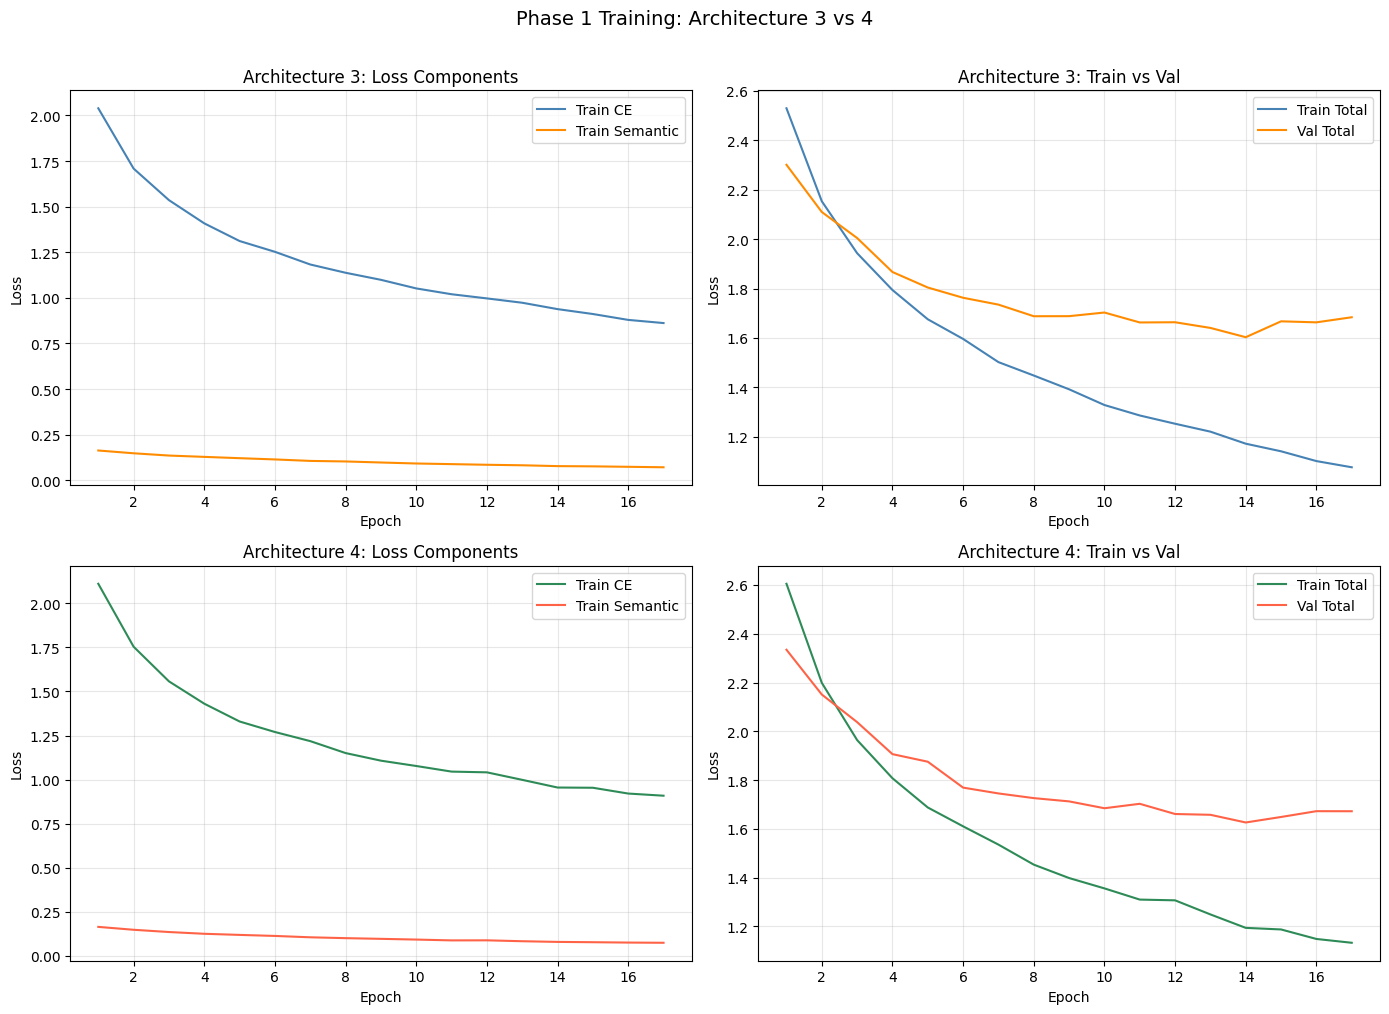

In [10]:
# ── Training Loss Plots (both architectures) ──────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = {3: ("steelblue", "darkorange"), 4: ("seagreen", "tomato")}

for row_idx, arch_id in enumerate([3, 4]):
    history = all_histories[arch_id]
    epochs  = range(1, len(history["train_total"]) + 1)
    c1, c2  = colors[arch_id]

    # Left: CE vs semantic components
    ax = axes[row_idx][0]
    ax.plot(epochs, history["train_ce"],  label="Train CE",      color=c1)
    ax.plot(epochs, history["train_sem"], label="Train Semantic", color=c2)
    ax.set_title(f"Architecture {arch_id}: Loss Components")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(alpha=0.3)

    # Right: Total train vs val
    ax = axes[row_idx][1]
    ax.plot(epochs, history["train_total"], label="Train Total", color=c1)
    ax.plot(epochs, history["val_loss"],    label="Val Total",   color=c2)
    ax.set_title(f"Architecture {arch_id}: Train vs Val")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Phase 1 Training: Architecture 3 vs 4", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Cell 11: Evaluation -- Generate Answers (Both Architectures)

Loops over both architectures, reloads each saved adapter, runs greedy generation on train/eval/test, saves CSVs into separate `architecture3/` and `architecture4/` subfolders.

In [12]:
# ── Evaluation -- Generate Answers (both architectures) ───────────────────────

def evaluate_generation(cfg, model, tokenizer, adapter, data, concept_vecs,
                         split_name: str, max_new_tokens: int = 128):
    # Generate answers for all examples using the trained adapter.
    adapter.eval()
    layer   = model.model.layers[cfg.injection_layer]
    results = []

    for item in tqdm(data, desc=f"Arch {cfg.architecture_id} | {split_name}"):
        vec = concept_vecs.get(item['entity_key'])
        if vec is None:
            generated = ""
        else:
            msgs       = [{"role": "user", "content": item['question']}]
            prompt_str = tokenizer.apply_chat_template(msgs, tokenize=False,
                                                       add_generation_prompt=True)
            inputs = tokenizer(prompt_str, return_tensors="pt").to(model.device)

            with torch.no_grad():
                injection_vec = adapter(
                    vec.unsqueeze(0).to(model.device, dtype=cfg.torch_dtype)
                ).squeeze(0)

            inject_idx = inputs["input_ids"].shape[1] - 1

            def single_hook(module, args, output):
                hs = output[0] if isinstance(output, tuple) else output
                if inject_idx < hs.shape[1]:
                    hs[0, inject_idx, :] = hs[0, inject_idx, :] + injection_vec
                return (hs,) + output[1:] if isinstance(output, tuple) else hs

            handle = layer.register_forward_hook(single_hook)
            try:
                with torch.no_grad():
                    out_ids = model.generate(
                        **inputs,
                        max_new_tokens=max_new_tokens,
                        do_sample=False,
                        pad_token_id=tokenizer.eos_token_id
                    )
            finally:
                handle.remove()

            generated = tokenizer.decode(
                out_ids[0][inputs["input_ids"].shape[1]:],
                skip_special_tokens=True
            )

        results.append({
            "category":  item["category_key"],
            "word":      item["entity_original"],
            "question":  item["question"],
            "generated": generated,
            "expected":  item["answer"],
        })

    out_dir  = os.path.join(cfg.base_dir, f"architecture{cfg.architecture_id}")
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir,
        f"{split_name}_results_L{cfg.injection_layer}_prompt{cfg.prompt_id}.csv")
    pd.DataFrame(results).to_csv(out_path, index=False)
    print(f"Saved {len(results)} results -> {out_path}")
    return results


# Run evaluation for both architectures across all splits
all_results = {}

for arch_id in [3, 4]:
    print(f"\n{'='*50}  Architecture {arch_id}  {'='*50}")
    cfg.architecture_id = arch_id

    # Reload saved adapter for this architecture — cast to model dtype
    adapter = build_adapter(cfg, model).to(model.device, dtype=cfg.torch_dtype)
    adapter.load_state_dict(torch.load(cfg.adapter_save_path, map_location=model.device))

    all_results[arch_id] = {
        "train": evaluate_generation(cfg, model, tokenizer, adapter,
                                     train_data, concept_vecs, "train"),
        "eval":  evaluate_generation(cfg, model, tokenizer, adapter,
                                     val_data, concept_vecs, "eval"),
        "test":  evaluate_generation(cfg, model, tokenizer, adapter,
                                     test_data, concept_vecs_test, "test"),
    }

print("\nAll evaluations complete.")


==================================================  Architecture 3  ==================================================
Adapter (Architecture 3): 4,195,328 parameters


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Saved 1389 results -> results_v3/architecture3/train_results_L16_prompt1.csv


Saved 279 results -> results_v3/architecture3/eval_results_L16_prompt1.csv


Saved 154 results -> results_v3/architecture3/test_results_L16_prompt1.csv

==================================================  Architecture 4  ==================================================
Adapter (Architecture 4): 33,562,624 parameters


Saved 1389 results -> results_v3/architecture4/train_results_L16_prompt1.csv


Saved 279 results -> results_v3/architecture4/eval_results_L16_prompt1.csv


Saved 154 results -> results_v3/architecture4/test_results_L16_prompt1.csv

All evaluations complete.


## Cell 12: LLM-as-a-Judge + Comparison Table

Runs Gemini judge on all CSVs for both architectures. Prints a side-by-side comparison table at the end with historical baselines.

In [10]:
from typing_extensions import TypedDict
import json
import time
import os
from dotenv import load_dotenv
load_dotenv()
import pandas as pd
from tqdm import tqdm
import google.generativeai as genai

# ── LLM-as-a-Judge (Gemini 2.5 Flash) ────────────────────────────────────────

# Define the expected JSON schema
class EvaluationResult(TypedDict):
    contains_entity: bool
    contains_entity_explanation: str
    matches_reference: bool
    matches_reference_explanation: str

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
genai.configure(api_key=GEMINI_API_KEY)
judge_model = genai.GenerativeModel('gemini-2.5-flash')

# Removed the manual JSON instruction since the API handles it now
EVALUATION_PROMPT = (
    "You are evaluating answers from a question-answering system.\n\n"
    "**Context:**\n"
    "- Entity: {word}\n"
    "- Question: {question}\n"
    "- Generated Answer: {generated}\n"
    "- Reference Answer: {expected}\n\n"
    "**Your Task:**\n"
    "Evaluate the generated answer on two dimensions:\n\n"
    "1. **Contains Entity**: Does the generated answer explicitly mention or reference the entity \"{word}\"?\n\n"
    "2. **Matches Reference**: Does the generated answer convey the same core information as the reference answer?\n"
    "   - They don't need to be word-for-word identical or even the same length.\n"
    "   - A short answer (even just the entity name) is correct if it provides the key information.\n"
    "   - Focus on whether the generated answer would be considered a correct response to the question."
)


def evaluate_single_row(row: dict) -> dict:
    prompt = EVALUATION_PROMPT.format(**row)
    try:
        # Force JSON via API config
        response = judge_model.generate_content(
            prompt,
            generation_config=genai.GenerationConfig(
                response_mime_type="application/json",
                response_schema=EvaluationResult
            )
        )

        # Fallback markdown stripping
        raw_text = response.text.strip()
        if raw_text.startswith("```json"):
            raw_text = raw_text[7:]
        if raw_text.startswith("```"):
            raw_text = raw_text[3:]
        if raw_text.endswith("```"):
            raw_text = raw_text[:-3]

        result = json.loads(raw_text.strip())
        return {
            "contains_entity":               result.get("contains_entity", False),
            "contains_entity_explanation":   result.get("contains_entity_explanation", ""),
            "matches_reference":             result.get("matches_reference", False),
            "matches_reference_explanation": result.get("matches_reference_explanation", ""),
        }
    except Exception as e:
        return {"contains_entity": False, "contains_entity_explanation": f"Error: {e}",
                "matches_reference": False, "matches_reference_explanation": f"Error: {e}"}


def evaluate_csv(csv_path: str) -> pd.DataFrame:
    out_path = csv_path.replace(".csv", "_evaluated.csv")
    df = pd.read_csv(csv_path)
    if os.path.exists(out_path) and 'contains_entity' in pd.read_csv(out_path).columns:
        print(f"  Already evaluated: {out_path}")
        return pd.read_csv(out_path)
    evals = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="  LLM-as-judge"):
        evals.append(evaluate_single_row(row.to_dict()))
        time.sleep(0.5)
    for key in evals[0]:
        df[key] = [e[key] for e in evals]
    df.to_csv(out_path, index=False)
    print(f"  Saved: {out_path}")
    return df


# Run judge on all splits for both architectures, then print comparison table
SPLITS = ["train", "eval", "test"]
summary = {}

for arch_id in [3, 4]:
    cfg.architecture_id = arch_id
    arch_dir = os.path.join(cfg.base_dir, f"architecture{arch_id}")
    summary[arch_id] = {}

    print(f"\n{'='*55}  Architecture {arch_id}  {'='*55}")
    for split in SPLITS:
        csv_path = os.path.join(arch_dir,
            f"{split}_results_L{cfg.injection_layer}_prompt{cfg.prompt_id}.csv")
        if os.path.exists(csv_path):
            df  = evaluate_csv(csv_path)
            # Safe numeric conversion to avoid crashing on old errors like "Error: Expecting value..."
            ce  = 100 * pd.to_numeric(df['contains_entity'], errors='coerce').mean()
            mr  = 100 * pd.to_numeric(df['matches_reference'], errors='coerce').mean()
            summary[arch_id][split] = (ce, mr)
            print(f"  {split:6s}: CE={ce:.1f}%  MR={mr:.1f}%")
        else:
            print(f"  {split:6s}: file not found")

# Final comparison table
print(f"\n{'='*60}")
print(f"{'COMPARISON SUMMARY':^60}")
print(f"{'='*60}")
print(f"{'Split':<8}  {'Arch3 CE':>9}  {'Arch3 MR':>9}  {'Arch4 CE':>9}  {'Arch4 MR':>9}")
print("-"*60)
for split in SPLITS:
    a3 = summary.get(3, {}).get(split, (float('nan'), float('nan')))
    a4 = summary.get(4, {}).get(split, (float('nan'), float('nan')))
    print(f"{split:<8}  {a3[0]:>8.1f}%  {a3[1]:>8.1f}%  {a4[0]:>8.1f}%  {a4[1]:>8.1f}%")


=======================================================  Architecture 3  =======================================================


  LLM-as-judge: 100%|██████████| 1389/1389 [1:06:32<00:00,  2.87s/it]


  Saved: results_v3/architecture3/train_results_L16_prompt1_evaluated.csv
  train : CE=89.6%  MR=86.3%


  LLM-as-judge: 100%|██████████| 279/279 [13:07<00:00,  2.82s/it]


  Saved: results_v3/architecture3/eval_results_L16_prompt1_evaluated.csv
  eval  : CE=82.8%  MR=80.6%


...

  Saved: results_v3/architecture4/train_results_L16_prompt1_evaluated.csv
  train : CE=88.0%  MR=83.9%


  LLM-as-judge: 100%|██████████| 279/279 [13:09<00:00,  2.83s/it]


  Saved: results_v3/architecture4/eval_results_L16_prompt1_evaluated.csv
  eval  : CE=85.7%  MR=80.6%


  LLM-as-judge: 100%|██████████| 154/154 [07:15<00:00,  2.83s/it]

  Saved: results_v3/architecture4/test_results_L16_prompt1_evaluated.csv
  test  : CE=12.3%  MR=11.7%

                     COMPARISON SUMMARY                     
Split      Arch3 CE   Arch3 MR   Arch4 CE   Arch4 MR
------------------------------------------------------------
train         89.6%      86.3%      88.0%      83.9%
eval          82.8%      80.6%      85.7%      80.6%
test          11.0%      10.4%      12.3%      11.7%


## Cell 13: Results Visualization (Both Architectures)

Category-level bar charts for each architecture x split combination (6 plots total).


============================== Architecture 3 ==============================
Plot saved: results_v3/evaluation_plots/arch3_train_L16_evaluation.png


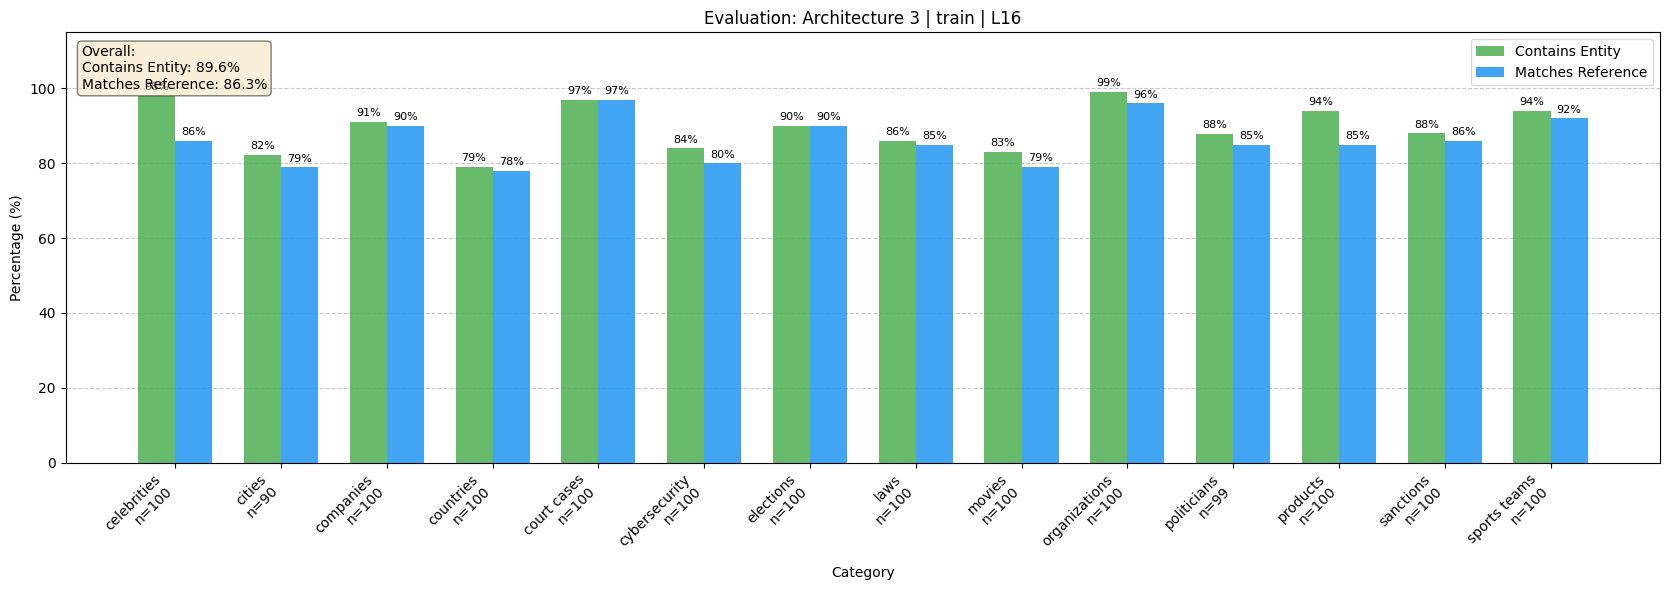

Plot saved: results_v3/evaluation_plots/arch3_eval_L16_evaluation.png


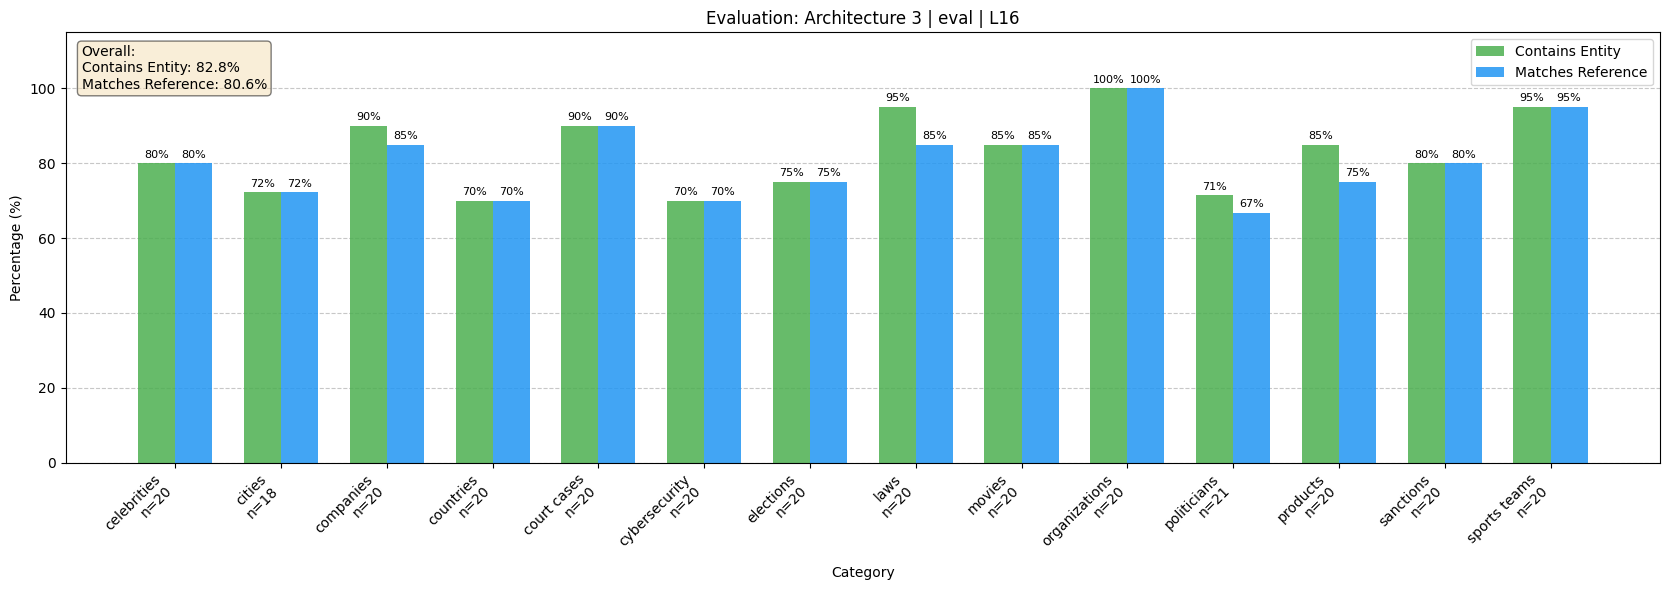

Plot saved: results_v3/evaluation_plots/arch3_test_L16_evaluation.png


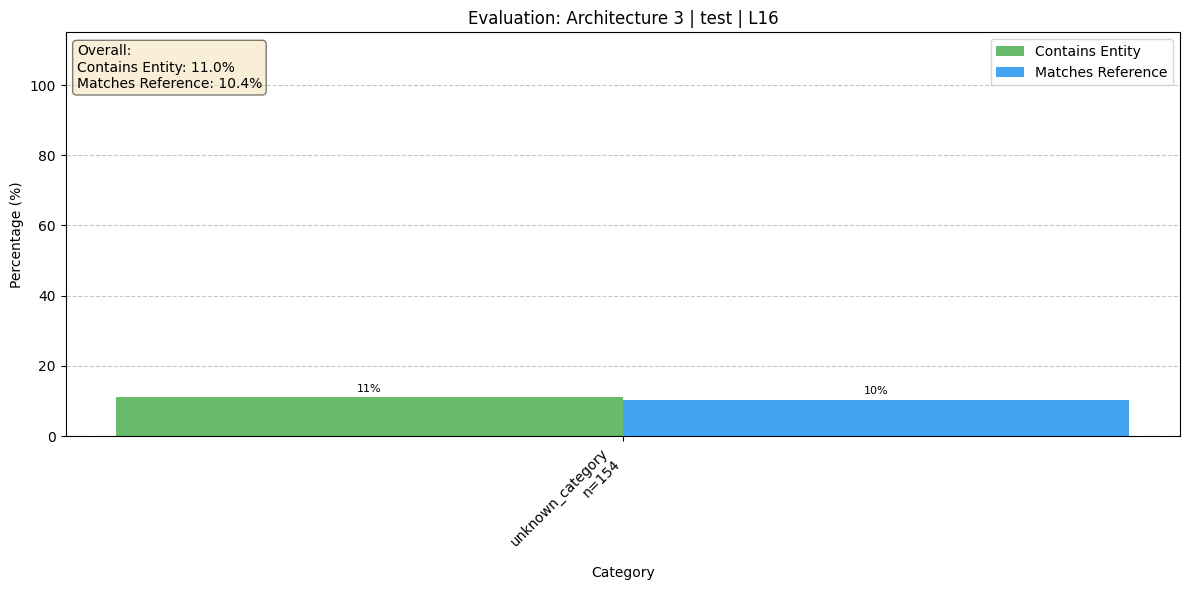


============================== Architecture 4 ==============================
Plot saved: results_v3/evaluation_plots/arch4_train_L16_evaluation.png


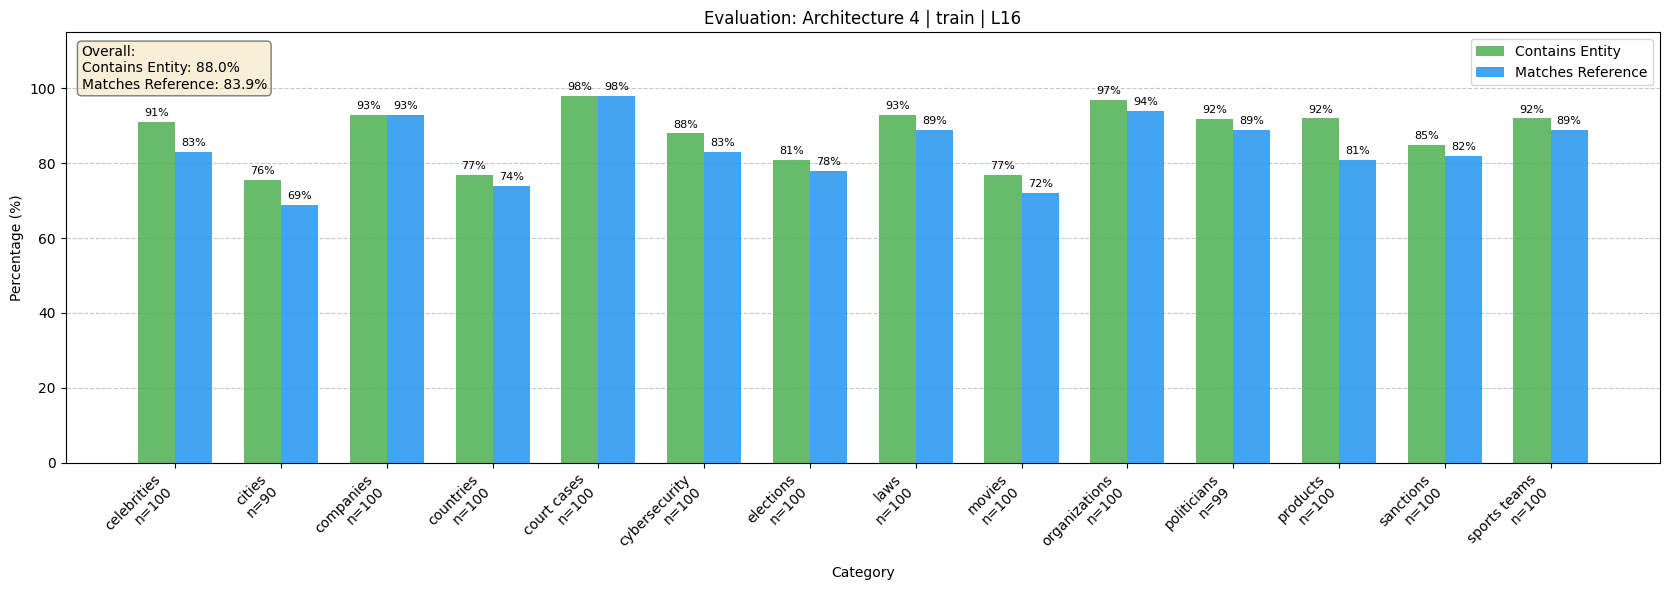

Plot saved: results_v3/evaluation_plots/arch4_eval_L16_evaluation.png


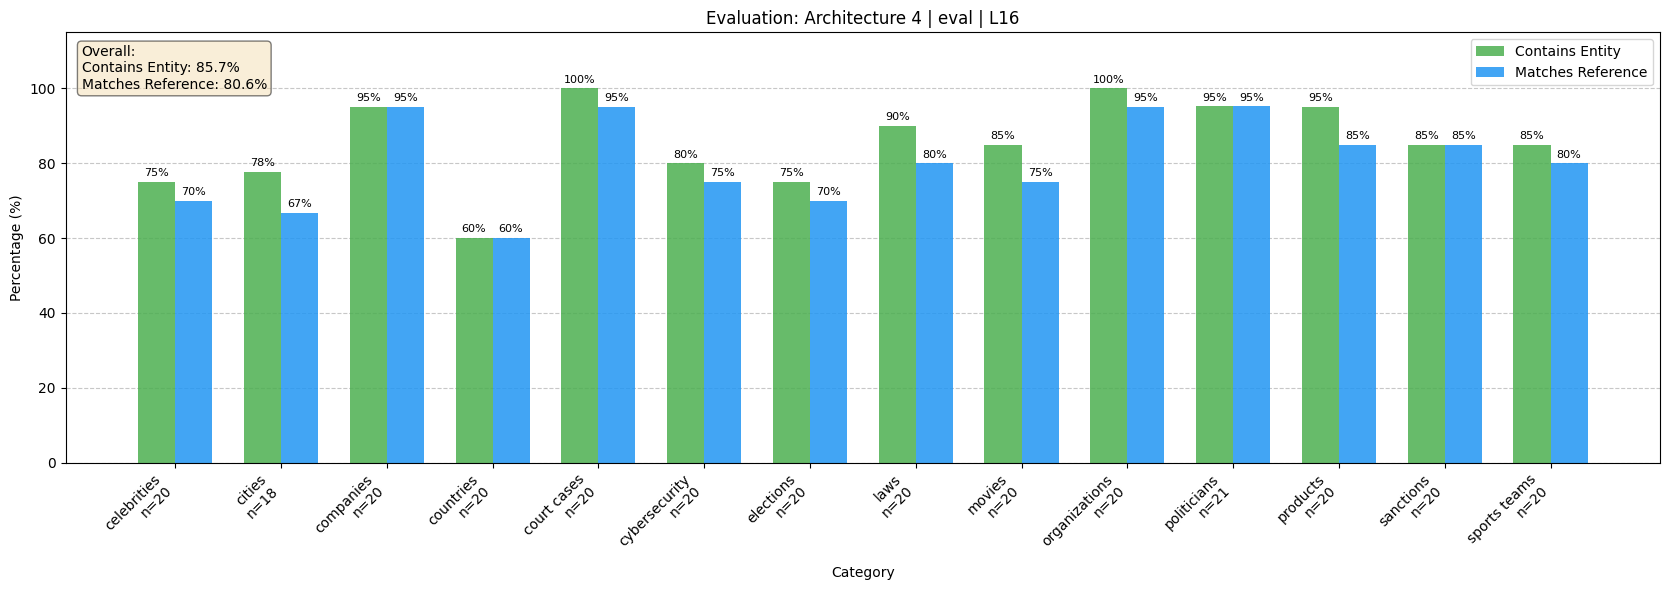

Plot saved: results_v3/evaluation_plots/arch4_test_L16_evaluation.png


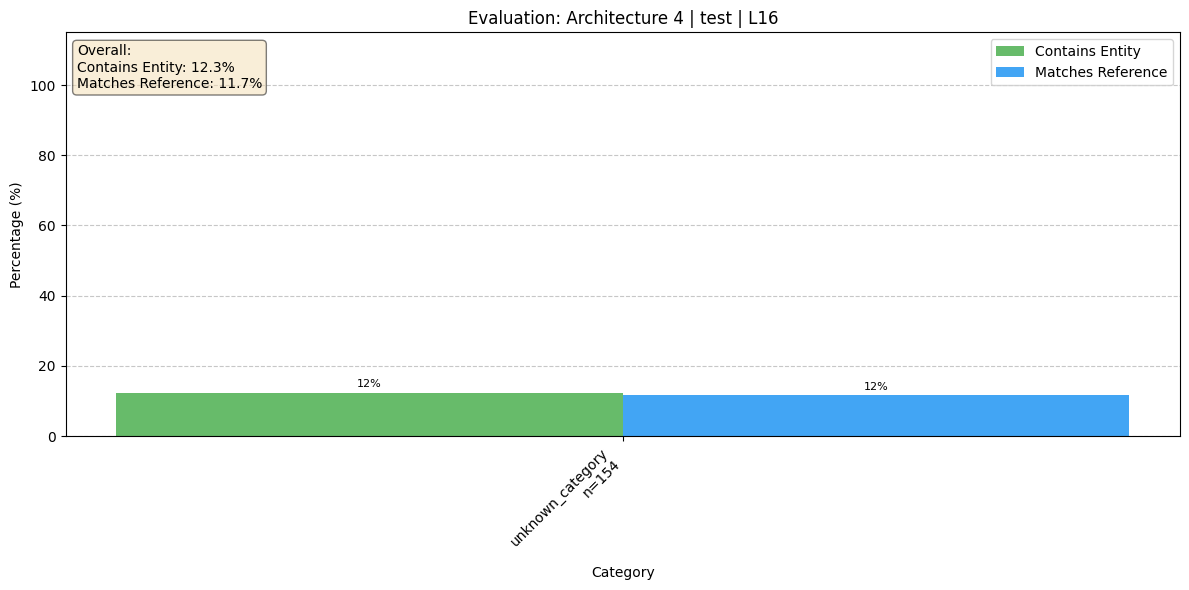

In [11]:
# ── Results Visualization (both architectures) ────────────────────────────────

PLOTS_DIR = os.path.join(cfg.base_dir, "evaluation_plots")
os.makedirs(PLOTS_DIR, exist_ok=True)


def plot_evaluation_by_category(arch_id: int, split: str):
    arch_dir = os.path.join(cfg.base_dir, f"architecture{arch_id}")
    fname    = f"{split}_results_L{cfg.injection_layer}_prompt{cfg.prompt_id}_evaluated.csv"
    csv_path = os.path.join(arch_dir, fname)

    if not os.path.exists(csv_path):
        print(f"File not found: {csv_path}")
        return None

    df = pd.read_csv(csv_path)
    if 'contains_entity' not in df.columns:
        print(f"Run LLM judge first on: {csv_path}")
        return None

    cat_metrics = df.groupby('category').agg(
        ce_pct = ('contains_entity',  lambda x: 100 * x.mean()),
        mr_pct = ('matches_reference', lambda x: 100 * x.mean()),
        count  = ('category', 'size')
    ).reset_index().sort_values('category')

    cats = cat_metrics['category'].tolist()
    x    = np.arange(len(cats))
    w    = 0.35

    fig, ax = plt.subplots(figsize=(max(12, len(cats) * 1.2), 6))
    b1 = ax.bar(x - w/2, cat_metrics['ce_pct'], w, label='Contains Entity',   color='#4CAF50', alpha=0.85)
    b2 = ax.bar(x + w/2, cat_metrics['mr_pct'], w, label='Matches Reference', color='#2196F3', alpha=0.85)

    for bar in [*b1, *b2]:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=8)

    overall_ce = 100 * df['contains_entity'].mean()
    overall_mr = 100 * df['matches_reference'].mean()

    ax.set_xticks(x)
    ax.set_xticklabels([f"{c}\nn={n}" for c, n in zip(cats, cat_metrics['count'])],
                       rotation=45, ha='right')
    ax.set_ylim(0, 115)
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel('Category')
    ax.set_title(f'Evaluation: Architecture {arch_id} | {split} | L{cfg.injection_layer}')
    ax.legend(loc='upper right')
    ax.text(0.01, 0.97,
            f'Overall:\nContains Entity: {overall_ce:.1f}%\nMatches Reference: {overall_mr:.1f}%',
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)
    plt.tight_layout()

    out = os.path.join(PLOTS_DIR, f"arch{arch_id}_{split}_L{cfg.injection_layer}_evaluation.png")
    plt.savefig(out, dpi=150, bbox_inches='tight')
    print(f"Plot saved: {out}")
    plt.show()
    plt.close()
    return cat_metrics


for arch_id in [3, 4]:
    print(f"\n{'='*30} Architecture {arch_id} {'='*30}")
    for split in ["train", "eval", "test"]:
        plot_evaluation_by_category(arch_id, split)
